ИМПОРТЫ

In [ ]:
# 1. Зависимости (только необходимое)
!python -m pip install -q pymorphy3 openpyxl pandas scikit-learn matplotlib seaborn wordcloud requests

# 2. Все импорты в одном месте
import os
import re
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymorphy3
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Парсинг отзывов через API

In [61]:
import os
import time
import requests
import pandas as pd

API_URL = "https://ms-gateway.tbank.ru/city/public/v2/feedback/search"

HEADERS = {
    'accept': '*/*',
    'accept-language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
    'content-type': 'application/json',
    'origin': 'https://www.tbank.ru',
    'referer': 'https://www.tbank.ru/',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36'
}

PAYLOAD = {
    "onlyText": True,
    "ratings": [],
    "bmsBrandId": 17525
}

all_reviews = []
next_page_token = None
max_reviews = 10000

start_time = time.time()

while len(all_reviews) < max_reviews:
    params = {
        "sort[0]": "id,desc",
        "sort[1]": "createdDate,desc",
        "size": 50  # Запрашиваем по 50 отзывов за 1 раз
    }
    
    if next_page_token:
        params["nextPage"] = next_page_token

    try:
        response = requests.post(API_URL, headers=HEADERS, params=params, json=PAYLOAD, timeout=10)
        
        if response.status_code != 200:
            print(f"Ошибка HTTP {response.status_code}: {response.text}")
            break
            
        data = response.json()
        
        # Извлекаем список отзывов из ключа 'content'
        items = data.get("content", [])
        next_page_token = data.get("nextPage")
        total_elements = data.get("totalElements", 0)
        
        if not items:
            print("Отзывы на сервере закончились.")
            break
            
        for item in items:
            review_id = item.get("id")
            text = item.get("text", "")
            rating = item.get("rating")
            created_date = item.get("createdDate")
            
            author = (
                item.get("authorName") 
                or item.get("clientName") 
                or item.get("author", {}).get("name") 
                or "Аноним"
            )
            
            if text:
                all_reviews.append({
                    "id": review_id,
                    "username": author,
                    "text": text,
                    "rating": rating,
                    "date": created_date
                })
        
        # Печатаем прогресс каждые 500 отзывов
        if len(all_reviews) % 500 == 0 or not next_page_token:
            elapsed = time.time() - start_time
            print(f" Собрано: {len(all_reviews)} / {min(max_reviews, total_elements)} | Время: {elapsed:.1f} сек")
            
        if not next_page_token:
            break
            
        time.sleep(0.08)
        
    except Exception as e:
        print(f"Ошибка выполнения: {e}")
        break

total_time = time.time() - start_time

if all_reviews:
    os.makedirs("data/raw", exist_ok=True)
    df = pd.DataFrame(all_reviews)
    df = df.drop_duplicates(subset=["id"])  # Точная дедупликация по ID отзыва
    
    output_file = "data/raw/reviews_raw.xlsx"
    df.to_excel(output_file, index=False)
    
    display(df.head(10))

 Собрано: 500 / 10000 | Время: 6.7 сек
 Собрано: 1000 / 10000 | Время: 15.2 сек
 Собрано: 1500 / 10000 | Время: 21.8 сек
 Собрано: 2000 / 10000 | Время: 27.7 сек
 Собрано: 2500 / 10000 | Время: 33.5 сек
 Собрано: 3000 / 10000 | Время: 40.3 сек
 Собрано: 3500 / 10000 | Время: 49.0 сек
 Собрано: 4000 / 10000 | Время: 57.8 сек
 Собрано: 4500 / 10000 | Время: 64.1 сек
 Собрано: 5000 / 10000 | Время: 70.2 сек
 Собрано: 5500 / 10000 | Время: 76.1 сек
 Собрано: 6000 / 10000 | Время: 82.2 сек
 Собрано: 6500 / 10000 | Время: 90.1 сек
 Собрано: 7000 / 10000 | Время: 97.2 сек
 Собрано: 7500 / 10000 | Время: 103.2 сек
 Собрано: 8000 / 10000 | Время: 109.5 сек
 Собрано: 8500 / 10000 | Время: 116.0 сек
 Собрано: 9000 / 10000 | Время: 122.8 сек
 Собрано: 9500 / 10000 | Время: 129.9 сек
 Собрано: 10000 / 10000 | Время: 137.2 сек


,id,username,text,rating,date
0,56383445,Алексей,Невероятно быстрая доставка,5,2026-07-28T11:19:59.740Z
1,56378895,Константин,"Мобильное приложение не очень, а так все круто",5,2026-07-27T07:50:35.855Z
2,56359668,Екатерина,"Стали очень долго доставлять , а сумма заказа от 1900",1,2026-07-21T07:41:35.315Z
3,56351031,Анна,👍,5,2026-07-19T07:22:39.213Z
4,56347872,Анна,"Скорость доставки и товары - вопросов нет. А вот к курьерам есть - оставляют заказ в подъезде, а не в тамбуре возле двери, комментарии для чего пишем, непонятно",4,2026-07-18T17:23:26.706Z
5,56345397,Александр,Скорость доставки радует,5,2026-07-17T19:51:30.145Z
6,56340141,Лина,"когда лень выходить из дома, всегда заказываю самокат, очень удобно",5,2026-07-16T10:51:25.701Z
7,56327824,Ярослав,лучшая доставка,5,2026-07-12T18:14:21.697Z
8,56324910,Арина,быстро привезли.,5,2026-07-11T17:43:16.601Z
9,56324368,Лилия,Все нравится . Доставка быстрая .,5,2026-07-11T14:50:41.018Z


2. Очистка текста + Лемматизация

In [63]:
import os
import re
import time
import pandas as pd
import pymorphy3

df = pd.read_excel("data/raw/reviews_raw.xlsx")

morph = pymorphy3.MorphAnalyzer()

# Предлоги и частицы, к которым НЕЛЬЗЯ приклеивать "НЕ" / "НИ"
PREPOSITIONS = {
    'в', 'на', 'из', 'к', 'с', 'по', 'о', 'об', 'от', 'до', 'у', 'за', 'над', 'под', 'при', 'для', 'без', 'через'
}

# Вайтлист частиц/местоимений с фиксированной формой
FIXED_FORMS = {
    'нибудь': 'нибудь',
    'таки': 'таки',
    'ка': 'ка',
    'либо': 'либо'
}

def remove_yo(text):
    """Полностью уничтожает букву 'ё' и ее юникод-двойники, переводя всё в 'е'"""
    replacements = {
        'ё': 'е', 'Ё': 'Е', 
        'ë': 'е', 'Ë': 'Е', 
        '\u0435\u0308': 'е', '\u0405\u0308': 'е' # Комбинированные символы с точками
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    return text

def ultra_clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Приводим к нижнему регистру и УБИРАЕМ 'Ё' -> 'Е'
    text = remove_yo(text.lower())
    
    # 2. Заменяем разделители предложений на явную точку
    text = re.sub(r'[\.\!\?\;\n\r]+', ' . ', text)
    
    # 3. Оставляем только русские буквы (без ё), английские, цифры и точки
    text = re.sub(r'[^а-яa-z0-9\.\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    lemmas = []
    i = 0
    
    while i < len(words):
        word = words[i]
        
        # Точка — граница предложений
        if word == '.':
            lemmas.append('.')
            i += 1
            continue
            
        # Умная склейка "НЕ" / "НИ"
        if word in ['не', 'ни'] and i + 1 < len(words):
            next_word = words[i+1]
            
            # Пропускаем предлоги и точки
            if next_word in PREPOSITIONS or next_word == '.':
                lemmas.append(word)
                i += 1
            else:
                # Нормализуем следующее слово
                if next_word in FIXED_FORMS:
                    next_lemma = FIXED_FORMS[next_word]
                elif re.match(r'^[а-я]+$', next_word):
                    next_lemma = morph.parse(next_word)[0].normal_form
                else:
                    next_lemma = next_word
                    
                lemmas.append(f"не_{next_lemma}")
                i += 2
        else:
            # Лемматизация обычного слова
            if word in FIXED_FORMS:
                lemma = FIXED_FORMS[word]
            elif re.match(r'^[а-я]+$', word):
                lemma = morph.parse(word)[0].normal_form
            else:
                lemma = word # Цифры и английские бренды оставляем
                
            lemmas.append(lemma)
            i += 1
            
    raw_result = " ".join(lemmas)
    
    # 4. Чистка точек: убираем пробел перед точкой, схлопываем повторы точек
    raw_result = re.sub(r'\s+\.', '.', raw_result)
    result = re.sub(r'(\.+)+', '. ', raw_result)
    result = re.sub(r'\s+', ' ', result).strip()
    
    return result


start_time = time.time()

df['text_clean'] = df['text'].apply(ultra_clean_text)

# Удаляем пустые строки
df_final = df[df['text_clean'].astype(str).str.strip() != ''].copy()


# Сохраняем результат
os.makedirs("data/processed", exist_ok=True)
final_file = "data/processed/reviews_final.xlsx"
df_final.to_excel(final_file, index=False)


3. Распределение оценок и динамика доли негативных

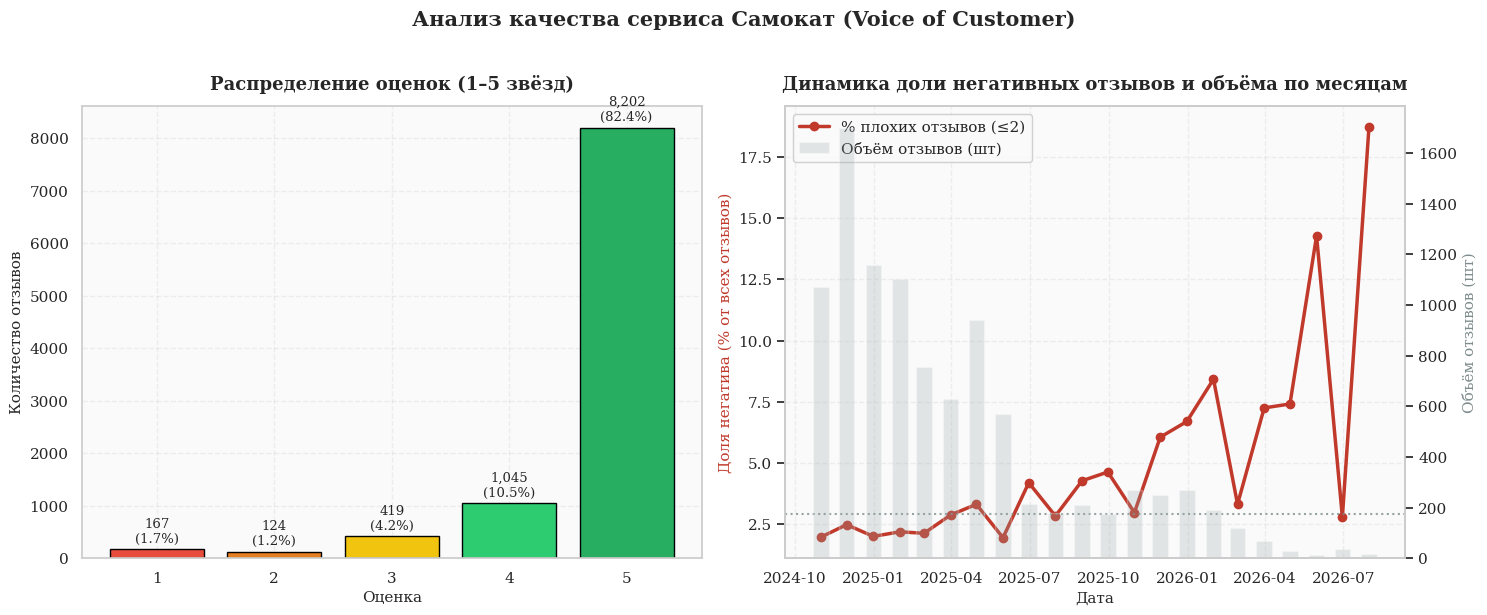

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Загрущка
df = pd.read_excel("data/processed/reviews_final.xlsx")
df['date'] = pd.to_datetime(df['date'], format='ISO8601').dt.tz_localize(None)

# Флаг негативного отзыва (1 или 2 звезды)
df['is_bad'] = df['rating'] <= 2

plt.rcParams.update({
    'figure.figsize': (15, 6),
    'font.size': 11,
    'font.family': 'serif',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# гистограмма оценок

rating_counts = df['rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

bars = ax1.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=1.0)
ax1.set_title('Распределение оценок (1–5 звёзд)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Оценка', fontsize=11)
ax1.set_ylabel('Количество отзывов', fontsize=11)
ax1.set_xticks(range(1, 6))

# Подписи над столбцами
for bar, count in zip(bars, rating_counts.values):
    pct = (count / len(df)) * 100
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 80,
             f'{count:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9.5)

ax1.grid(axis='y', alpha=0.3)

# 2. Динамика Доли негатива
# Агрегация по месяцам: доля негатива (%) и общее число отзывов
monthly = df.set_index('date').resample('ME').agg(
    bad_share=('is_bad', lambda x: x.mean() * 100),
    total_count=('rating', 'count')
)

# Вторая ось Y для объёма отзывов (столбцы на заднем плане)
ax2_vol = ax2.twinx()
ax2_vol.bar(monthly.index, monthly['total_count'], width=18, color='#95a5a6', alpha=0.25, label='Объём отзывов (шт)')
ax2_vol.set_ylabel('Объём отзывов (шт)', color='#7f8c8d', fontsize=11)
ax2_vol.grid(False) # убираем сетку второй оси, чтобы не накладывалась

# Линия доли негатива (на переднем плане)
ax2.plot(monthly.index, monthly['bad_share'], 'o-', color='#c0392b', linewidth=2.5, markersize=6, label='% плохих отзывов (≤2)')
ax2.set_title('Динамика доли негативных отзывов и объёма по месяцам', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Дата', fontsize=11)
ax2.set_ylabel('Доля негатива (% от всех отзывов)', color='#c0392b', fontsize=11)

# Горизонтальная линия среднего процента негатива за весь период
avg_bad_share = df['is_bad'].mean() * 100
ax2.axhline(y=avg_bad_share, color='#7f8c8d', linestyle=':', linewidth=1.5, alpha=0.8)


# Объединенная легенда для двух осей
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_vol.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9)

plt.suptitle('Анализ качества сервиса Самокат (Voice of Customer)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_report.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


4. Моделирование (LogReg & Веса N-грамм)

In [65]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Подготовка данных (исключаем 3 звезды)
df_ml = df[df['rating'] != 3].copy()
df_ml['is_neg'] = (df_ml['rating'] <= 2).astype(int)

# 2. Обучение TF-IDF + LogReg на устойчивых биграммах/триграммах (min_df=25)
tfidf = TfidfVectorizer(ngram_range=(2, 3), min_df=25)
X = tfidf.fit_transform(df_ml['text_clean'])
feature_names = tfidf.get_feature_names_out()

model = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0)
model.fit(X, df_ml['is_neg'])

# 3. расчет частот
# Передам тот же ngram_range=(2, 3) для фраз
count_vec = CountVectorizer(ngram_range=(2, 3), vocabulary=feature_names)
X_counts = count_vec.transform(df_ml['text_clean'])

neg_mask = (df_ml['is_neg'] == 1).values
pos_mask = (df_ml['is_neg'] == 0).values

counts_neg = np.array(X_counts[neg_mask].sum(axis=0)).flatten()
counts_pos = np.array(X_counts[pos_mask].sum(axis=0)).flatten()

# 4. сборка результатов
phrases_df = pd.DataFrame({
    'phrase': feature_names,
    'coef': model.coef_[0],
    'count_neg': counts_neg,
    'count_pos': counts_pos,
    'total': counts_neg + counts_pos
})

# 5. Мусор
noise_stoplist = [
    'так банк', 'быстро удобно но', 'быстро но', 'удобно но', 
    'первый раз', 'несколько раз', 'тот же', 'но это', 'что вы', 'какой то'
]

clean_phrases = phrases_df[~phrases_df['phrase'].isin(noise_stoplist)].copy()

# 6. Вывод топов
top_pains = clean_phrases.sort_values(by='coef', ascending=False).head(10)
top_praises = clean_phrases.sort_values(by='coef', ascending=True).head(10)

print("🔴 ТОП-10 ХАРАКТЕРНЫХ ЖАЛОБ (Очищенный LogReg, min_df=25):")
print("=" * 70)
print(f"{'№':<3} | {'Фраза':<28} | {'Негатив':<8} | {'Позитив':<8} | {'Всего'}")
print("-" * 70)
for i, (_, r) in enumerate(top_pains.iterrows(), 1):
    print(f"{i:<3} | {r['phrase']:<28} | {int(r['count_neg']):<8} | {int(r['count_pos']):<8} | {int(r['total'])}")

print("\n🟢 ТОП-10 ХАРАКТЕРНЫХ ПОХВАЛ (Очищенный LogReg, min_df=25):")
print("=" * 70)
print(f"{'№':<3} | {'Фраза':<28} | {'Позитив':<8} | {'Негатив':<8} | {'Всего'}")
print("-" * 70)
for i, (_, r) in enumerate(top_praises.iterrows(), 1):
    print(f"{i:<3} | {r['phrase']:<28} | {int(r['count_pos']):<8} | {int(r['count_neg']):<8} | {int(r['total'])}")

🔴 ТОП-10 ХАРАКТЕРНЫХ ЖАЛОБ (Очищенный LogReg, min_df=25):
№   | Фраза                        | Негатив  | Позитив  | Всего
----------------------------------------------------------------------
1   | не_всегда свежий             | 4        | 23       | 27
2   | привозить продукт            | 1        | 29       | 30
3   | готовый еда                  | 8        | 101      | 109
4   | 20 минута                    | 4        | 31       | 35
5   | качество продукт             | 6        | 82       | 88
6   | фрукт овощ                   | 3        | 28       | 31
7   | служба поддержка             | 5        | 36       | 41
8   | выбор продукт                | 1        | 68       | 69
9   | продукт но                   | 2        | 25       | 27
10  | доставка на                  | 2        | 26       | 28

🟢 ТОП-10 ХАРАКТЕРНЫХ ПОХВАЛ (Очищенный LogReg, min_df=25):
№   | Фраза                        | Позитив  | Негатив  | Всего
------------------------------------------------------------

5. Аспектный анализ (Aspect-Based Sentiment Analysis) и оценка сервиса

                      aspects  Количество  Средний_рейтинг  Доля_%
               Цены и наценка        1563             4.37    15.7
Качество и свежесть продуктов        1113             4.45    11.2
               Работа курьера        1215             4.59    12.2
Служба поддержки и приложение         988             4.61     9.9
                  Ассортимент         947             4.68     9.5
 Скорость и задержки доставки        3622             4.76    36.4
                       Прочее        3741             4.82    37.6


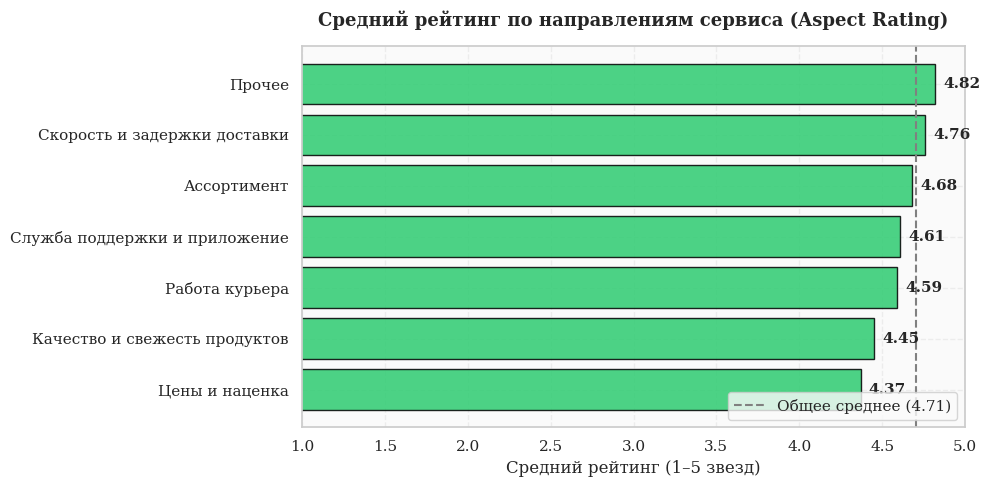

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Словарь аспектов (составлен строго по ключевым маркерам из нашего LogReg/EDA)
aspects_dict = {
    'Качество и свежесть продуктов': [
        'свежий', 'просрочка', 'срок годность', 'испортить', 'плесень', 
        'тухлый', 'гнилой', 'готовый еда', 'фрукт овощ', 'качество продукт'
    ],
    'Скорость и задержки доставки': [
        'быстро', 'долго', 'скорость', 'опаздывать', 'задержка', 
        'время', 'минута', '20 минута', '15 минута', 'отменять заказ'
    ],
    'Цены и наценка': [
        'дорого', 'цена', 'наценка', 'дешевый', 'скидка', 
        'промокод', 'акция', 'высокий цена', 'высокий'
    ],
    'Служба поддержки и приложение': [
        'приложение', 'сайт', 'баг', 'зависать', 'ошибка', 
        'служба поддержка', 'поддержка', 'чат', 'вернуть деньги'
    ],
    'Работа курьера': [
        'курьер', 'вежливый', 'грубый', 'доставщик', 'парень', 'привозить'
    ],
    'Ассортимент': [
        'выбор', 'ассортимент', 'мало', 'разнообразие', 'выбор продукт'
    ]
}

def tag_aspects(text):
    if not isinstance(text, str):
        return ['Прочее']
    found = [aspect for aspect, kws in aspects_dict.items() if any(kw in text for kw in kws)]
    return found if found else ['Прочее']

# 2. Размечаем каждый отзыв (отзыв может содержать несколько аспектов)
df['aspects'] = df['text_clean'].apply(tag_aspects)
exploded = df.explode('aspects')

# 3. Агрегируем метрики
aspect_summary = exploded.groupby('aspects')['rating'].agg(
    Количество='count',
    Средний_рейтинг='mean'
).reset_index()

aspect_summary['Доля_%'] = ((aspect_summary['Количество'] / len(df)) * 100).round(1)
aspect_summary['Средний_рейтинг'] = aspect_summary['Средний_рейтинг'].round(2)
aspect_summary = aspect_summary.sort_values(by='Средний_рейтинг')


print(aspect_summary.to_string(index=False))

# 4. График среднего рейтинга по категориям
plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if r < 4.2 else '#2ecc71' for r in aspect_summary['Средний_рейтинг']]

bars = plt.barh(aspect_summary['aspects'], aspect_summary['Средний_рейтинг'], color=colors, edgecolor='black', alpha=0.85)
plt.axvline(x=df['rating'].mean(), color='gray', linestyle='--', label=f"Общее среднее ({df['rating'].mean():.2f})")
plt.xlim(1, 5)
plt.title('Средний рейтинг по направлениям сервиса (Aspect Rating)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Средний рейтинг (1–5 звезд)')
plt.legend(loc='lower right')

# Значения на барах
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, f'{width:.2f}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('aspect_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

6. Анализ от LLM GEMINI

In [ ]:

import os
import time
import requests
import pandas as pd
from dotenv import load_dotenv

# 1. Загружаем строго СЫРОЙ файл с диска
raw_path = "data/raw/reviews_raw.xlsx"

if not os.path.exists(raw_path):
    raise FileNotFoundError(f"❌ Файл {raw_path} не найден! Проверь запуск парсера.")

print(f"📂 Загружаем сырой датасет: {raw_path}")
df_raw = pd.read_excel(raw_path)

print(f"📌 Загружено строк: {len(df_raw)} | Колоночный состав: {df_raw.columns.tolist()}")

# 2. Загрузка API-ключа из .env
load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError("❌ Ключ GOOGLE_API_KEY не найден в файле .env!")

# 3. Безопасное сэмплирование по оценкам (без багов pandas.groupby.apply)
df_valid = df_raw.dropna(subset=['rating', 'text']).copy()

sampled_groups = []
for rating_val, group in df_valid.groupby('rating'):
    # Берем до 150 отзывов на каждую оценку
    n_samples = min(len(group), 150)
    sampled_groups.append(group.sample(n=n_samples, random_state=42))

sample_df = pd.concat(sampled_groups, ignore_index=True)

# Формируем сырой текстовый контекст для Gemini
reviews_payload = "\n".join([f"[{int(r)}★]: {t}" for r, t in zip(sample_df['rating'], sample_df['text'])])

print(f"📊 Сформирована выборка из {len(sample_df)} сырых отзывов для передачи в Gemini.")

# 4. Функция обращения к Gemini REST API
def generate_voc_report(reviews_text, model="gemini-2.0-flash"):
    url = f"https://generativelanguage.googleapis.com/v1beta/models/{model}:generateContent?key={GOOGLE_API_KEY}"

    prompt = f"""
    Ты — Lead Product Analyst в e-commerce и сервисах экспресс-доставки (Voice of Customer). 
    Проанализируй репрезентативную выборку реальных отзывов клиентов.

    Твоя задача — подготовить емкий, структурированный бизнес-отчет для C-level руководства:

    1. 🎯 **Главные драйверы удовлетворенности:** Что клиенты хвалят больше всего и почему верны сервису?
    2. 🚨 **Критические боли и точки оттока (Pains):** Основные проблемы в продукте, качестве товаров, логистике и приложении.
    3. 💡 **Action Plan (Конкретные шаги по улучшению):** 3–5 приоритетных бизнес-рекомендаций для продуктовой и операционной команд.

    Стиль: Строгий, лаконичный, продуктовый. Без абстрактных фраз и «воды». Довольно сжатый вывод с фактами. Весь ответ пиши по русски. Не выдумывай Факты. Недавай точных цифр . Можешь цитировать отзывы.

    СЫРЫЕ ОТЗЫВЫ КЛИЕНТОВ:
    {reviews_text}
    """

    payload = {
        "contents": [{"parts": [{"text": prompt}]}],
        "generationConfig": {
            "temperature": 0.3,
            "maxOutputTokens": 4096
        }
    }

    headers = {'Content-Type': 'application/json'}

    try:
        response = requests.post(url, headers=headers, json=payload, timeout=30)
        result = response.json()

        if response.status_code == 200:
            return result['candidates'][0]['content']['parts'][0]['text']
        else:
            error_msg = result.get('error', {}).get('message', 'Unknown error')
            if "Quota exceeded" in error_msg:
                return f"❌ Квота модели {model} исчерпана."
            return f"Ошибка API ({response.status_code}): {error_msg}"
    except Exception as e:
        return f"Ошибка соединения: {e}"

# 5. Запуск с авто-перебором моделей
models_to_try = ["gemini-3.6-flash", "gemini-3.5-flash-lite", "gemini-3.5-flash", "gemini-3.1-flash-lite"]

print("🚀 Отправка сырых данных в Gemini...")

for model in models_to_try:
    print(f"🔄 Пробую модель: {model}...")
    report = generate_voc_report(reviews_payload, model)

    if "❌ Квота модели" not in report and "Ошибка API" not in report:
        print("\n" + "="*70)
        print("🤖 EXECUTIVE SUMMARY & ACTION PLAN (GEMINI):")
        print("="*70)
        print(report)
        print("="*70)
        break
    else:
        print(f"   {report}")
        time.sleep(2)
else:
    print("❌ Все модели временно недоступны.")

📂 Загружаем сырой датасет: data/raw/reviews_raw.xlsx
📌 Загружено строк: 10000 | Колоночный состав: ['id', 'username', 'text', 'rating', 'date']
📊 Сформирована выборка из 724 сырых отзывов для передачи в Gemini.
🚀 Отправка сырых данных в Gemini...
🔄 Пробую модель: gemini-3.6-flash...

🤖 EXECUTIVE SUMMARY & ACTION PLAN (GEMINI):
# Аналитический отчет Voice of Customer (VoC): Сервис экспресс-доставки «Самокат»

**Кому:** C-Level Руководству (CEO, CPO, COO)  
**От кого:** Lead Product Analyst (Voice of Customer)  
**Предмет анализа:** Репрезентативная выборка отзывов клиентов (1★–5★)  
**Ключевой вывод:** Сервис находится в фазе деградации базового ценностного предложения (UVP). Главное преимущество — «доставка за 15 минут» — систематически нарушается, а рост чека и цен не компенсируется качеством товаров (высокая доля брака в категорий FRESH и готовой еде). Это приводит к оттоку лояльной базы к конкурентам (Яндекс Лавка, Купер).

---

## 1. 🎯 Главные драйверы удовлетворенности (Что держит